# Computing n-Dimensional Polygons & Recursively Inscribed Fractals #

$Author$: Michael Simons

$Class$: MTH 337 - Mathematical & Scientific Computing

$Date$: 9/23/22

## Introduction

Consider an algorithm in which an initial point $p_0$ is randomly selected, which lies inside a regular polygon.

A random vertex $v$ of the polygon is then selected, and point $p_1$ is computed by adding a fraction of the distance between $p_0$ and $v$ to $p_0$. The same procedure is now followed with respect to $p_1$ to compute another point $p_2$, continuing recursively.

This report will seek to implement and explore this algorithm


## Computing & Visualizing Regular Polygons

Implementing and exploring the algorithm has some requirements. Firstly, a procedure to compute vertices of a regular polygon. This can be done by calculating points based on a unit circle's parametric equations, and a given amount of vertices. To account for the necessity to plot the points, an extra point will be added to produce a closed shape.

In [1]:
import numpy as np
#Given n vertices, computes a regular polygon as a list.
def vertices(n):
    count=0
    acc=[]                      #Initialize accumulator for points
    while(count<n+1):           #Iterate once extra to collect a duplicate point
        i=2*count*np.pi/n       #Update the amplitude/period
        x_value=np.cos(i)       #Compute points x,y based on the unit circle
        y_value=np.sin(i)
        point=(x_value,y_value) #Add the point to the accumulator
        acc.insert(0,point)     #Asymptotically faster than append
        count+=1
    return acc                  #Computed in the form [(x1,y1),(xn,yn),(xn-1,yn-1)...(x1,y1)]

With a method of computing the vertices of a polygon, matplotlib can be used to visualize the shape with simplicity. A function to plot these points will be beneficial for future use, and therefore will be produced.

In [2]:
import matplotlib.pyplot as plt
#Plots a shape given a list of vertices
def plot_shape(n):
    points=vertices(n)
    x_values=[v[0] for v in points] #Gather x values
    y_values=[v[1] for v in points] #Gather y values
    plt.plot(x_values,y_values,'k-')#Plot values in black
    plt.axis("Equal")               #Align the axis properly
    plt.title(f'Vertices:{n}')      #Label each shape's amount of vertices
    plt.xticks([])                  #Remove redundant x and y tick labels
    plt.yticks([])
    return

To assert the correctness of the functions, a multitude of polygons will be displayed.

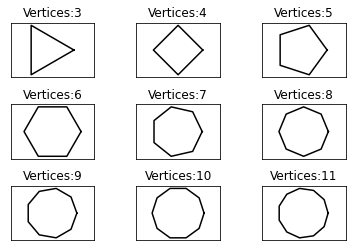

In [3]:
for i in range(1,10):                         #3x3=9 positions
    plt.subplot(3,3,i)                        #Update position in 3x3 grid
    plot_shape(i+2)                           #Add two to begin at a triangle
plt.subplots_adjust(hspace=0.5,wspace=0.5)    #Adjust width/height parameters 
plt.show()

Observably, the `vertices` function correctly computes points of a regular polygon, and the `plot_shape` function displays it successfully.

## Implementing the algorithm



Now that there is a mechanism to compute and view regular polygons, a means of computing a random point inside is necessary to explore the algorithm. To select an initial point, NumPy can be used to generate a random point and Matplotlib can be used to verify that the point is contained within the perimeter of the polygon. This can be done repeatedly until an initial point is validated.

In [4]:
import matplotlib.path as path
#Select a random point inside the given polygon
def pick_p0(verts):                                   
    u=1 if(np.random.rand()>0.5) else -1                 #50/50 chance for positive or negative 1
    rand_dec=np.random.rand()*u                          #Generate a random decimal between -1 and 1
    point=(rand_dec,rand_dec)                            #Initialize the point
    while(not path.Path(verts).contains_point(point)):   #Verify the point is in the shape
        rand_dec=np.random.rand()                        #Generate another random point until found
        point=(rand_dec,rand_dec)
    return point                                         #Found point

After computing the first random point in the polygon, the second step in the algorithm is to compute a point between a randomly chosen vertex and the first computed point. Numpy will be utilized to randomly select a vertex. A point will be found by computing a fraction of the distance between the original point and the vertex, and adding it to the original point.

In [5]:
#Given vertices and a point p0 inside a shape, computes a point between p0 and a random vertex by a factor f
def pick_p1(verts,p0,f=0.5):
    rand_vert=verts[np.random.randint(0,len(verts))]  #Select a random index of the vertex list
    diff=(rand_vert[0]-p0[0],rand_vert[1]-p0[1])      #Calculate the distance between the initial point and the chosen vertex
    new_point=(p0[0]+(f*diff[0]),p0[1]+(f*diff[1]))   #Add the fraction of the distance to the original point
    return new_point

The function will now be used to compute 750 points inside a triangle as to verify correctness.

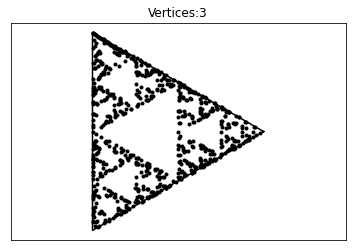

In [12]:
plot_shape(3)                 #Plot the triangle
v=vertices(3)                 #Compute the vertices
count=0                       #Inialize count
p=pick_p0(v)                  #Compute initial point
while(count<750):
    plt.plot(p[0],p[1],'k.')  #Plot 500 points
    p=pick_p1(v[1:],p)        #Update p to p1
    count+=1                  #Inc.

## Conclusion


This report demonstrates a method for computing and visualizing regular polygons, and then explores an algorithm for recursively generating points within a polygon.